**AI/ML Internship — Week 2**                                    
**Data Analysis with
NumPy & Pandas**                                          
**Dataset:** Titanic — Machine Learning from Disaster                                       
**Student Name**: [Usman Asif]                                                   
**Date**: [26 april,26]

**PART A — NUMPY DEEP DIVE & DATA LOADING**

**Step 1 — NumPy Warm-Up — Broadcasting & Masking**

In [2]:
import numpy as np

# (a) Create matrix
data = np.random.randint(0, 101, (6,4))
print("Original Matrix:\n", data)

# (b) Normalize using broadcasting
normalized = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))
print("\nNormalized Matrix:\n", normalized)

# (c) Mask for students >= 60
avg = data.mean(axis=1)
mask = avg >= 60
print("\nStudents Avg >= 60:\n", data[mask])

# (d) Replace <40 with column mean
col_mean = data.mean(axis=0)
data_fixed = np.where(data < 40, col_mean, data)
print("\nScores after replacing <40:\n", data_fixed)

# (e) Dot product
weights = np.random.rand(4)
weighted_scores = normalized.dot(weights)
print("\nWeighted Scores:\n", weighted_scores)

Original Matrix:
 [[31 55 55 65]
 [32 65 58 84]
 [25  8 89 12]
 [33 70 71 80]
 [68 48 90  4]
 [74 47 36 32]]

Normalized Matrix:
 [[0.12244898 0.75806452 0.35185185 0.7625    ]
 [0.14285714 0.91935484 0.40740741 1.        ]
 [0.         0.         0.98148148 0.1       ]
 [0.16326531 1.         0.64814815 0.95      ]
 [0.87755102 0.64516129 1.         0.        ]
 [1.         0.62903226 0.         0.35      ]]

Students Avg >= 60:
 [[33 70 71 80]]

Scores after replacing <40:
 [[43.83333333 55.         55.         65.        ]
 [43.83333333 65.         58.         84.        ]
 [43.83333333 48.83333333 89.         46.16666667]
 [43.83333333 70.         71.         80.        ]
 [68.         48.         90.         46.16666667]
 [74.         47.         66.5        46.16666667]]

Weighted Scores:
 [1.05459765 1.28063167 0.82410267 1.52670911 1.65043136 0.9758979 ]


**Step 2 — Load Dataset & Full Initial Inspection**

In [3]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

print(df.head(10))
print(df.tail(5))
print(df.sample(8, random_state=42))

print("Shape:", df.shape)
print(df.info())
print("Dtypes:\n", df.dtypes)
print("Columns:", df.columns.tolist())

# Counts
cat_cols = df.select_dtypes(include='object').shape[1]
num_cols = df.select_dtypes(exclude='object').shape[1]
missing_cols = df.isnull().any().sum()
total_missing = df.isnull().sum().sum()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)
print("Columns with missing:", missing_cols)
print("Total missing cells:", total_missing)

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

**Step 3 — Missing Value Deep Analysis**

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


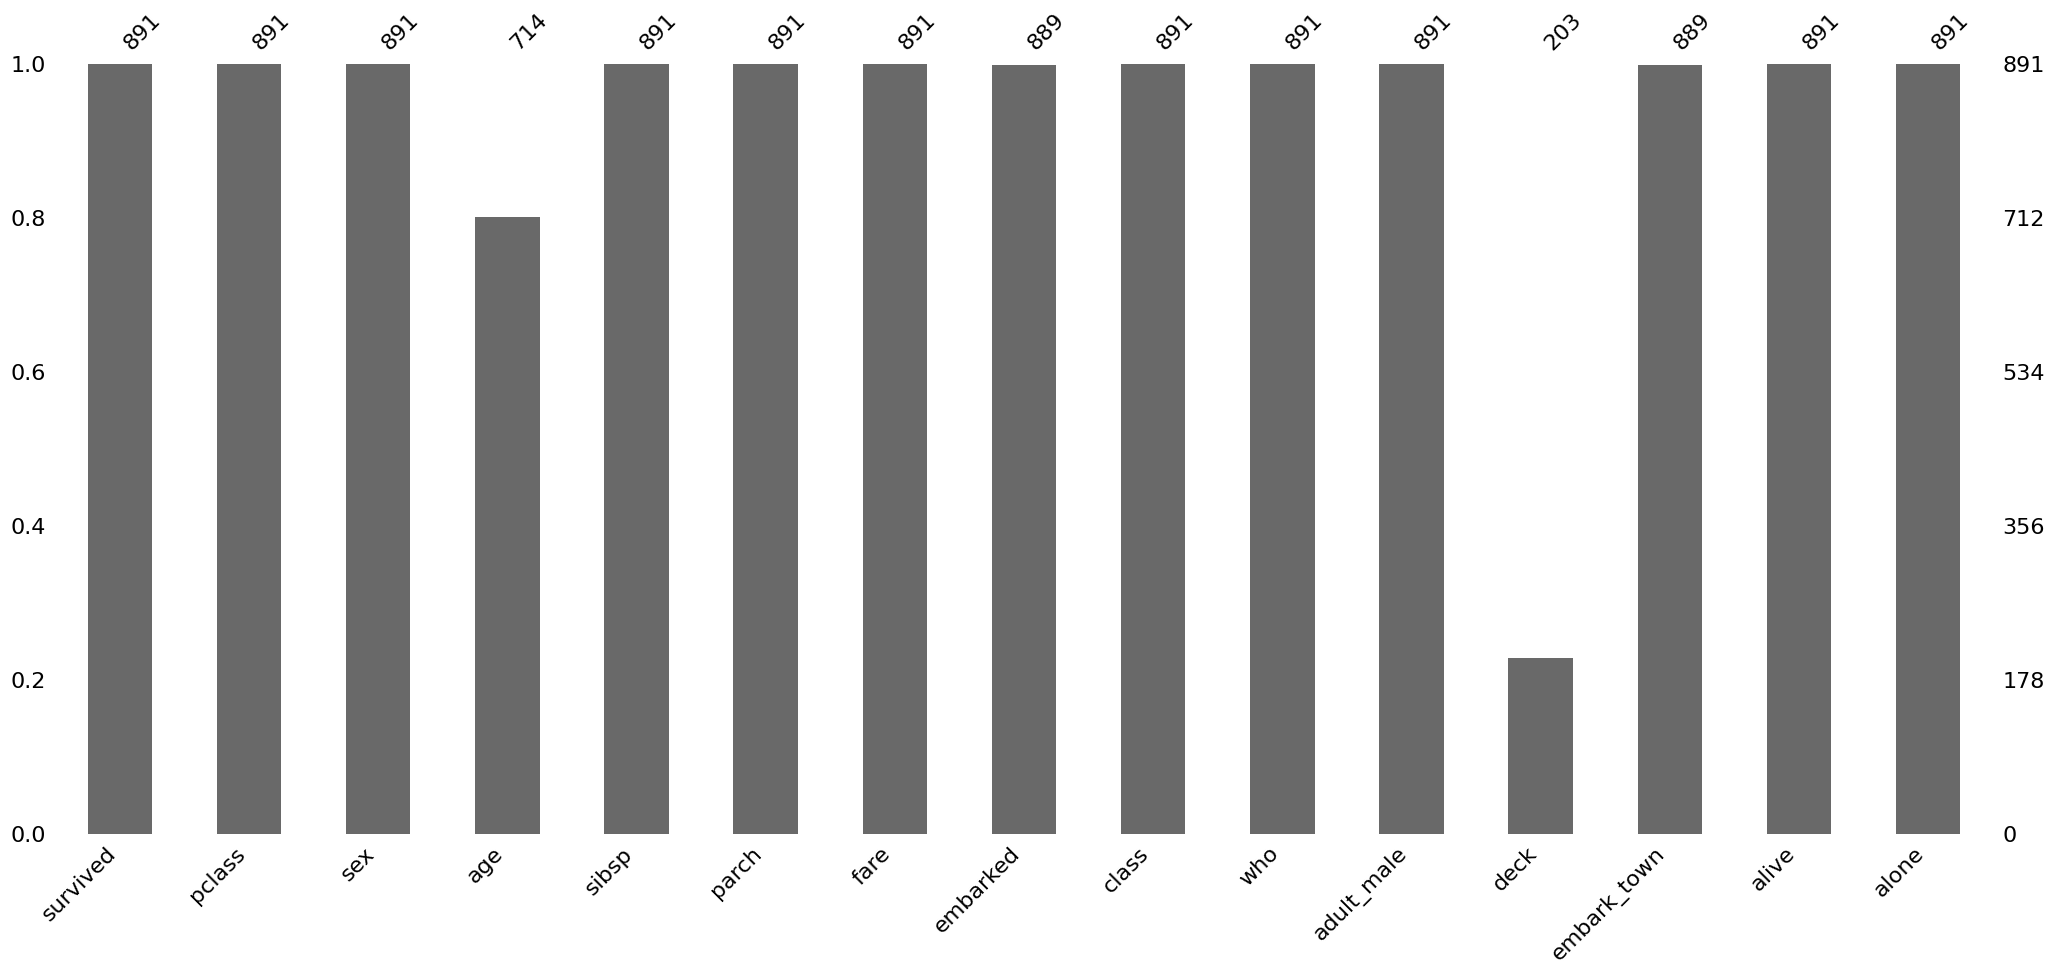

In [4]:
import missingno as msno
import matplotlib.pyplot as plt

print(df.isnull().sum())
print((df.isnull().mean()*100))

msno.bar(df)
plt.show()

**Step 4 — Data Type Audit & Correction**

In [5]:
before = df.dtypes

df['survived'] = df['survived'].astype('category')
df['pclass'] = df['pclass'].astype('category')

after = df.dtypes

print(pd.DataFrame({'Before': before, 'After': after}))

               Before     After
survived        int64  category
pclass          int64  category
sex            object    object
age           float64   float64
sibsp           int64     int64
parch           int64     int64
fare          float64   float64
embarked       object    object
class        category  category
who            object    object
adult_male       bool      bool
deck         category  category
embark_town    object    object
alive          object    object
alone            bool      bool


**PART B — DATA CLEANING & FEATURE ENGINEERING**

**Step 5 — Handle Missing Values — Professional Strategy**

In [6]:
# Age → group median
df['age'] = df.groupby(['pclass','sex'], observed=False)['age'] \
              .transform(lambda x: x.fillna(x.median()))

# Embarked → mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Extra column in seaborn dataset
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Cabin equivalent → deck
df['has_cabin'] = df['deck'].notnull().astype(int)

# Drop original deck column
df = df.drop('deck', axis=1)

# Final check
print("Remaining Missing:", df.isnull().sum().sum())

Remaining Missing: 0


**Step 6 — Outlier Detection & Treatment**

Fare Outliers Count: 116
Age Outliers Count: 33


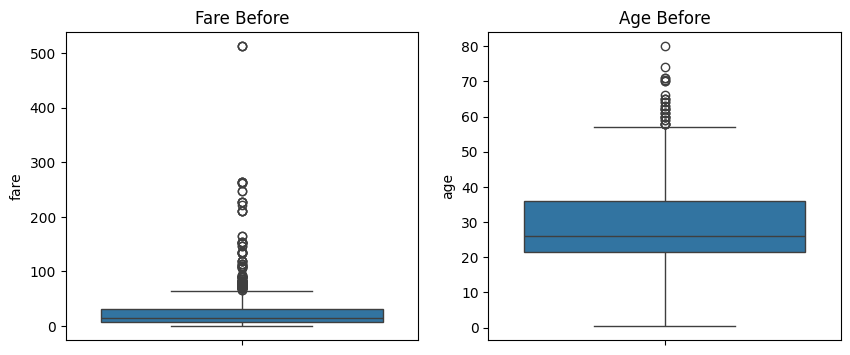

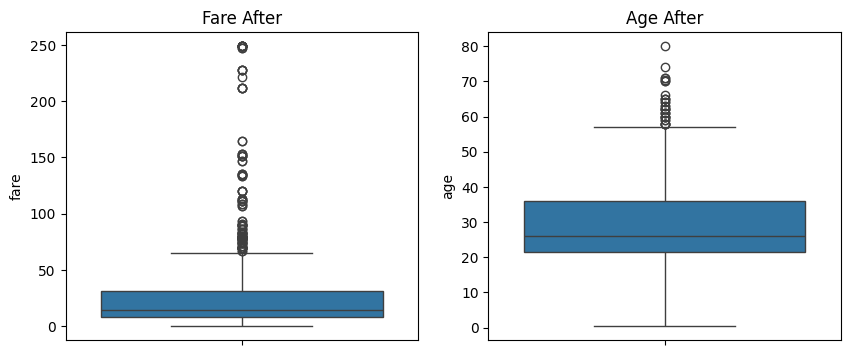

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------- FARE -----------
Q1_f = df['fare'].quantile(0.25)
Q3_f = df['fare'].quantile(0.75)
IQR_f = Q3_f - Q1_f

lower_f = Q1_f - 1.5 * IQR_f
upper_f = Q3_f + 1.5 * IQR_f

fare_outliers = df[(df['fare'] < lower_f) | (df['fare'] > upper_f)]
print("Fare Outliers Count:", fare_outliers.shape[0])

# ----------- AGE -----------
Q1_a = df['age'].quantile(0.25)
Q3_a = df['age'].quantile(0.75)
IQR_a = Q3_a - Q1_a

lower_a = Q1_a - 1.5 * IQR_a
upper_a = Q3_a + 1.5 * IQR_a

age_outliers = df[(df['age'] < lower_a) | (df['age'] > upper_a)]
print("Age Outliers Count:", age_outliers.shape[0])

# ----------- BOXPLOT BEFORE -----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['fare'])
plt.title("Fare Before")

plt.subplot(1,2,2)
sns.boxplot(y=df['age'])
plt.title("Age Before")
plt.show()

# ----------- TREATMENT (FARE ONLY) -----------
cap = df['fare'].quantile(0.99)
df['fare'] = df['fare'].clip(upper=cap)

# ----------- BOXPLOT AFTER -----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['fare'])
plt.title("Fare After")

plt.subplot(1,2,2)
sns.boxplot(y=df['age'])
plt.title("Age After")
plt.show()

**Step 7 — Feature Engineering**

In [8]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

df['is_alone'] = (df['family_size'] == 1).astype(int)

df['fare_per_person'] = df['fare'] / df['family_size']

df['title'] = df['who']  # seaborn replacement

df['age_group'] = pd.cut(df['age'],
                        bins=[0,12,17,60,100],
                        labels=['Child','Teen','Adult','Senior'])

# use extracted deck
# df['deck_letter'] already created in Step 5

df['fare_bin'] = pd.qcut(df['fare'], 4,
                        labels=['Low','Medium','High','VHigh'])

**Step 8 — Encoding Categorical Variables**

In [9]:
# (a) Label Encoding (Sex)
df['sex_encoded'] = df['sex'].map({'male':0,'female':1})

# (b) One-Hot Encoding (Embarked)
df = pd.get_dummies(df, columns=['embarked'])

# (c) One-Hot Encoding (Title)
df = pd.get_dummies(df, columns=['title'], drop_first=True)

# (d) Ordinal Encoding
age_map = {'Child':0,'Teen':1,'Adult':2,'Senior':3}
df['age_group'] = df['age_group'].map(age_map)

fare_map = {'Low':0,'Medium':1,'High':2,'VHigh':3}
df['fare_bin'] = df['fare_bin'].map(fare_map)

# Check shape
print("Shape after encoding:", df.shape)

# Show new columns
print("\nNew Columns:")
print([col for col in df.columns if 'embarked' in col or 'title' in col])

Shape after encoding: (891, 25)

New Columns:
['embarked_C', 'embarked_Q', 'embarked_S', 'title_man', 'title_woman']


**ML FEATURE LIST**

In [10]:
features = [
    'pclass','sex_encoded','age','fare',
    'family_size','is_alone','fare_per_person',
    'age_group','fare_bin'
]

# Add dynamically generated columns
features += [col for col in df.columns if 'embarked_' in col]
features += [col for col in df.columns if 'title_' in col]

print("Final Feature List:")
print(features)

Final Feature List:
['pclass', 'sex_encoded', 'age', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'age_group', 'fare_bin', 'embarked_C', 'embarked_Q', 'embarked_S', 'title_man', 'title_woman']


**Step 9 — Feature Scaling & Final ML-Ready Dataset**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['age','fare','fare_per_person','family_size']

print("Before Scaling:")
print(df[cols].mean())
print(df[cols].std())

df[cols] = scaler.fit_transform(df[cols])

print("\nAfter Scaling:")
print(df[cols].mean())
print(df[cols].std())

# Final dataset
final_df = df.drop(['who','adult_male','alive','class','embark_town'], axis=1)

print(final_df.info())
print(final_df.head())

# Save
final_df.to_csv("titanic_cleaned.csv", index=False)

Before Scaling:
age                29.112424
fare               31.224767
fare_per_person    19.161062
family_size         1.904602
dtype: float64
age                13.304424
fare               42.524125
fare_per_person    28.386818
family_size         1.613459
dtype: float64

After Scaling:
age                2.153160e-16
fare              -5.582266e-17
fare_per_person    1.993666e-17
family_size       -2.392400e-17
dtype: float64
age                1.000562
fare               1.000562
fare_per_person    1.000562
family_size        1.000562
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   survived         891 non-null    category
 1   pclass           891 non-null    category
 2   sex              891 non-null    object  
 3   age              891 non-null    float64 
 4   sibsp            891 non-null    int64   
 5

**PART C — ADVANCED GROUPBY & STATISTICAL ANALYSIS**

**Step 10 — Survival Analysis — Multi-Factor GroupBy**

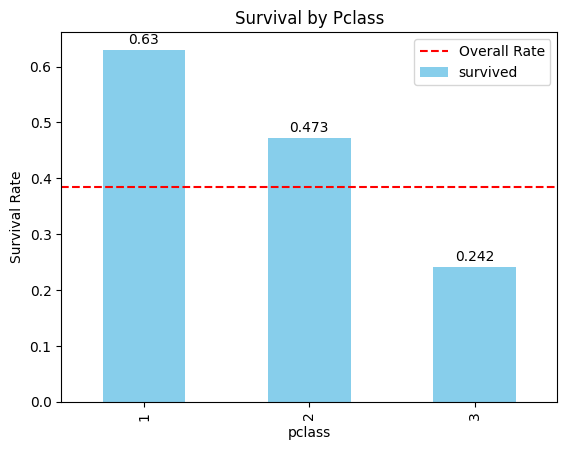

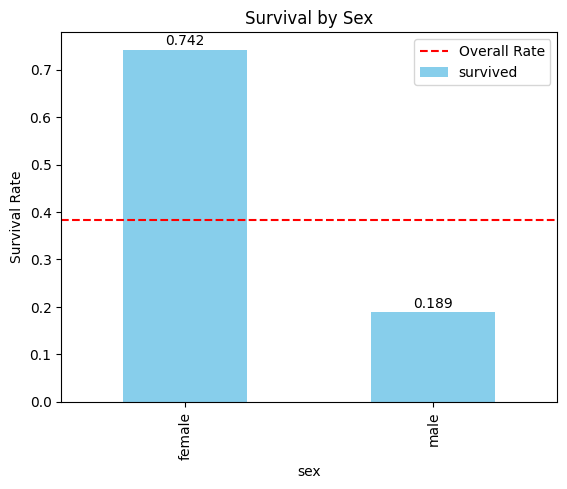

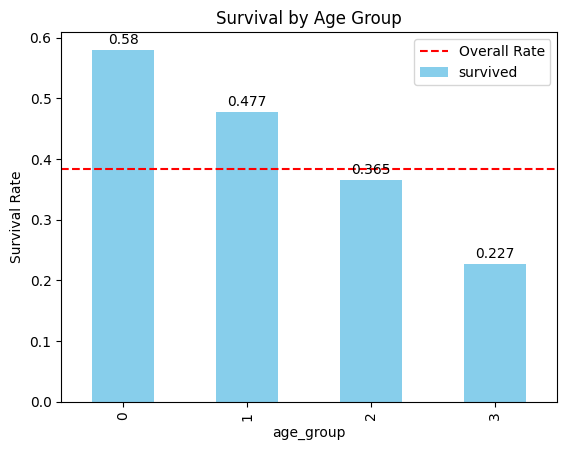

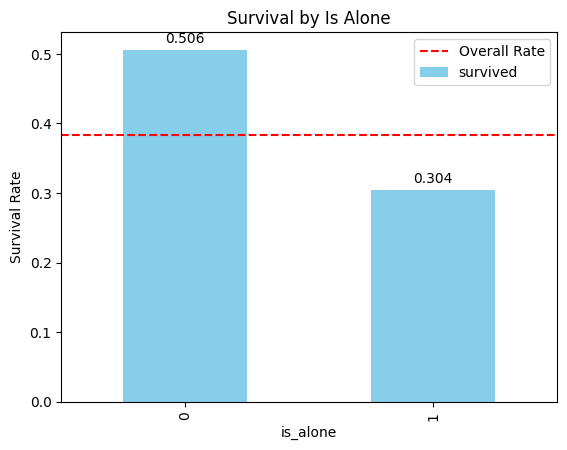

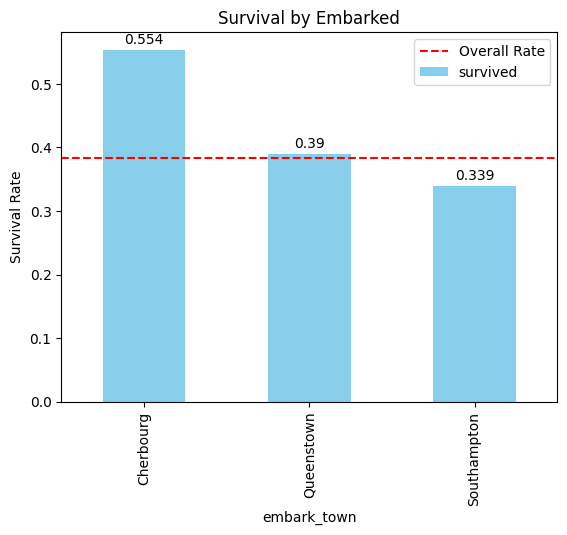

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

overall_rate = df['survived'].astype(int).mean()

def plot_bar(data, title):
    ax = data.plot(kind='bar', color='skyblue')

    plt.axhline(overall_rate, color='red', linestyle='--', label='Overall Rate')

    for i, v in enumerate(data):
        ax.text(i, round(v,3)+0.01, round(v,3), ha='center')

    plt.title(title)
    plt.ylabel("Survival Rate")
    plt.legend()
    plt.show()

# -------------------
# PCLASS
pclass_rate = df.groupby('pclass', observed=False)['survived'].apply(lambda x: x.astype(int).mean()).round(3)
plot_bar(pclass_rate, "Survival by Pclass")

# -------------------
# SEX
sex_rate = df.groupby('sex', observed=False)['survived'].apply(lambda x: x.astype(int).mean()).round(3)
plot_bar(sex_rate, "Survival by Sex")

# -------------------
# AGE GROUP
age_rate = df.groupby('age_group', observed=False)['survived'].apply(lambda x: x.astype(int).mean()).round(3)
plot_bar(age_rate, "Survival by Age Group")

# -------------------
# IS ALONE
alone_rate = df.groupby('is_alone', observed=False)['survived'].apply(lambda x: x.astype(int).mean()).round(3)
plot_bar(alone_rate, "Survival by Is Alone")

# -------------------
# EMBARKED
emb_rate = df.groupby('embark_town', observed=False)['survived'].apply(lambda x: x.astype(int).mean()).round(3)
plot_bar(emb_rate, "Survival by Embarked")

**Step 11 — Advanced Aggregation — agg() with Custom Functions**

In [13]:
agg = df.groupby('pclass', observed=False).agg({
    'fare':['mean','median','std','min','max', lambda x:(x>50).mean()],
    'age':['mean','median', lambda x:x.quantile(0.75)-x.quantile(0.25)],
    'survived':[lambda x: x.astype(int).mean(),'count']
})

print(agg)

# Transform
df['class_avg_fare'] = df.groupby('pclass')['fare'].transform('mean')
df['class_survival_rate'] = df.groupby('pclass')['survived'].transform(lambda x: x.astype(int).mean())

print(df[['pclass','fare','class_avg_fare','survived','class_survival_rate']].head(15))

           fare                                                          age  \
           mean    median       std       min       max <lambda_0>      mean   
pclass                                                                         
1       1.15034  0.683825  1.453492 -0.734696  5.124239        0.0  0.688732   
2      -0.24853 -0.399404  0.315702 -0.734696  0.994705        0.0  0.056463   
3      -0.41292 -0.545285  0.277131 -0.734696  0.901765        0.0 -0.324145   

                              survived        
          median <lambda_0> <lambda_0> count  
pclass                                        
1       0.668392   1.372495   0.629630   216  
2       0.066750   0.977667   0.472826   184  
3      -0.309276   0.658045   0.242363   491  
   pclass      fare  class_avg_fare survived  class_survival_rate
0       3 -0.564109        -0.41292        0             0.242363
1       1  0.942548         1.15034        1             0.629630
2       3 -0.548227        -0.41292    

/tmp/ipykernel_2667/1841440602.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['class_avg_fare'] = df.groupby('pclass')['fare'].transform('mean')
/tmp/ipykernel_2667/1841440602.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['class_survival_rate'] = df.groupby('pclass')['survived'].transform(lambda x: x.astype(int).mean())


**Step 12 — Pivot Table Analysis**

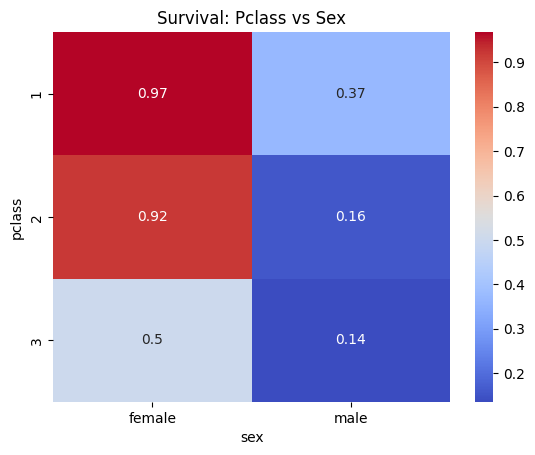

           <lambda>                     count          
pclass            1         2         3     1    2    3
age_group                                              
0          0.750000  1.000000  0.416667     4   17   48
1          1.000000  0.666667  0.300000     8    6   30
2          0.642105  0.411392  0.218137   190  158  408
3          0.214286  0.333333  0.200000    14    3    5


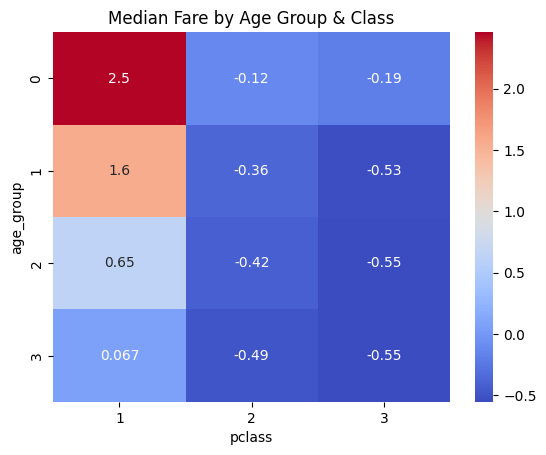

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# (a)
pivot1 = pd.pivot_table(df, values='survived', index='pclass', columns='sex', aggfunc=lambda x: x.astype(int).mean(), observed=False)
sns.heatmap(pivot1, annot=True, cmap='coolwarm')
plt.title("Survival: Pclass vs Sex")
plt.show()

# (b)
pivot2 = pd.pivot_table(df, values='survived',
                        index='age_group',
                        columns='pclass',
                        aggfunc=[lambda x: x.astype(int).mean(),'count'], observed=False)
print(pivot2)

# (c)
pivot3 = pd.pivot_table(df, values='fare',
                        index='age_group',
                        columns='pclass',
                        aggfunc='median', observed=False)

sns.heatmap(pivot3, annot=True, cmap='coolwarm')
plt.title("Median Fare by Age Group & Class")
plt.show()

**Step 13 — Correlation Analysis — Full Feature Set**

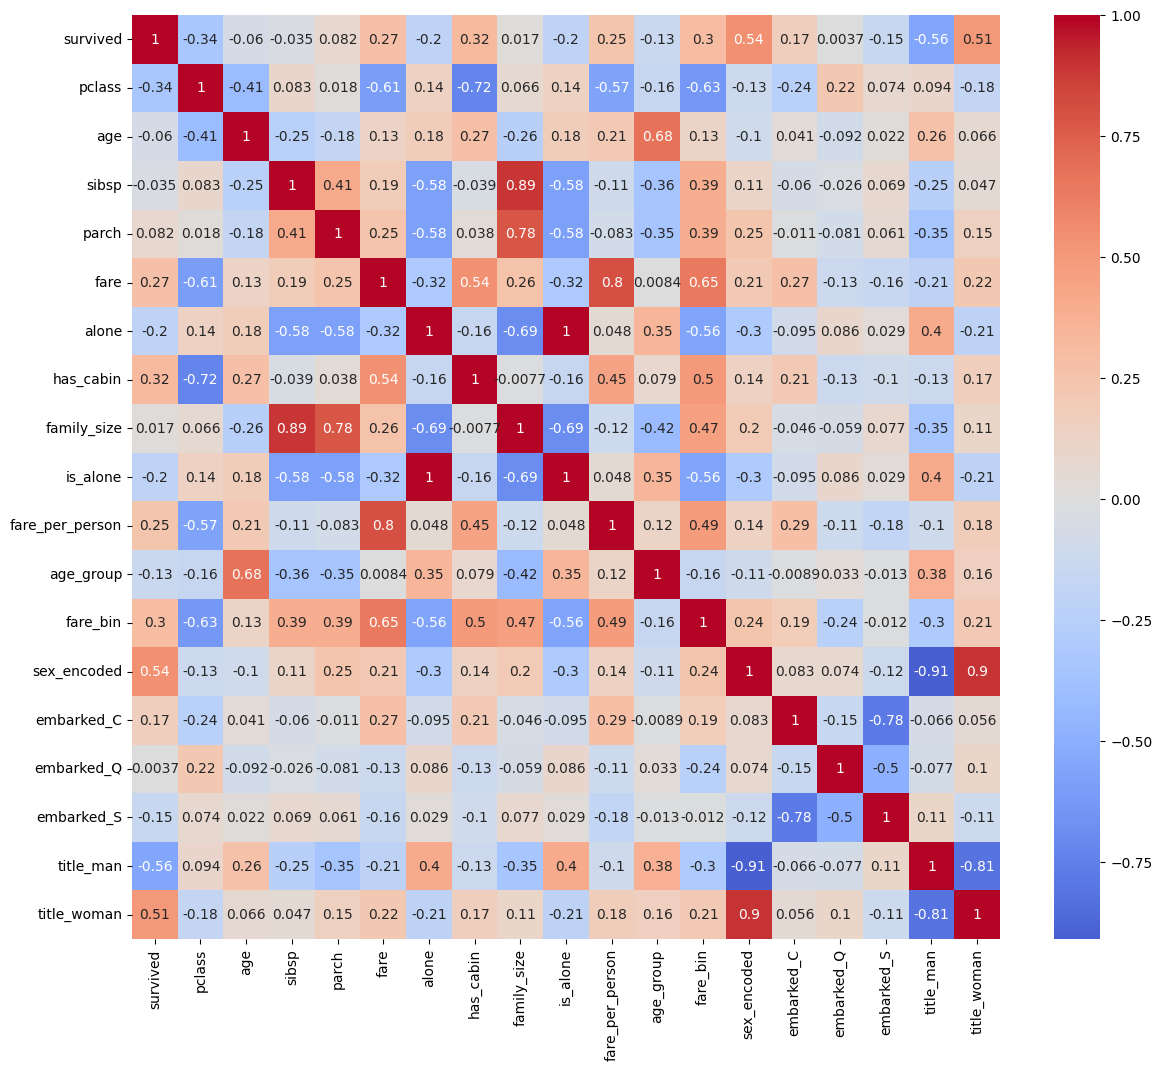

survived           1.000000
sex_encoded        0.543351
title_woman        0.506562
has_cabin          0.319572
fare_bin           0.299357
fare               0.273008
fare_per_person    0.246441
embarked_C         0.168240
parch              0.081629
family_size        0.016639
embarked_Q         0.003650
sibsp             -0.035322
age               -0.059579
age_group         -0.134611
embarked_S        -0.149683
is_alone          -0.203367
alone             -0.203367
pclass            -0.338481
title_man         -0.557080
Name: survived, dtype: float64


In [15]:
corr = final_df.drop('sex', axis=1).corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

# Ranked correlation
corr_target = corr['survived'].sort_values(ascending=False)
print(corr_target)

**PART D — FINAL DASHBOARD, NUMPY ANALYSIS & REPORT**

**Step 14 — NumPy Performance & Survival Computation**

In [16]:
import numpy as np

# Extract numerical values ONLY
arr = final_df.select_dtypes(include=['float64','int64']).values

print("===== BASIC STATISTICS (NUMPY ONLY) ====")

print("Mean:\n", np.mean(arr, axis=0))
print("Std:\n", np.std(arr, axis=0))
print("Min:\n", np.min(arr, axis=0))
print("Max:\n", np.max(arr, axis=0))
print("Median:\n", np.median(arr, axis=0))

# =========================
# Z-SCORE MATRIX
# =========================
z = (arr - np.mean(arr, axis=0)) / np.std(arr, axis=0)

print("\n===== Z-SCORE CHECK ====")
print("Mean after z-score (should be ~0):\n", np.mean(z, axis=0))
print("Std after z-score (should be ~1):\n", np.std(z, axis=0))

# =========================
# CORRELATION (NUMPY)
# =========================
corr_numpy = np.corrcoef(arr.T)

print("\n===== NUMPY CORRELATION MATRIX =====\n", corr_numpy)

# Compare with Pandas
print("\n===== PANDAS CORRELATION =====\n", final_df.drop('sex', axis=1).corr().values)

# =========================
# SURVIVOR ANALYSIS
# =========================
survived = arr[final_df['survived'].values == 1]
dead = arr[final_df['survived'].values == 0]

print("\n===== SURVIVAL COMPARISON ====")

print("Survivors Avg Age:", np.mean(survived[:,1]))
print("Dead Avg Age:", np.mean(dead[:,1]))

print("Survivors Avg Fare:", np.mean(survived[:,2]))
print("Dead Avg Fare:", np.mean(dead[:,2]))

diff = np.mean(survived[:,2]) - np.mean(dead[:,2])

print("\nDifference in Fare:", diff)

===== BASIC STATISTICS (NUMPY ONLY) ====
Mean:
 [ 2.15315981e-16  5.23007856e-01  3.81593715e-01 -5.58226616e-17
  2.27833895e-01 -2.39239978e-17  6.02693603e-01  1.99366649e-17
  3.52413019e-01]
Std:
 [1.         1.10212444 0.80560476 1.         0.41943487 1.
 0.4893404  1.         0.47772176]
Min:
 [-2.157819    0.          0.         -0.734696    0.         -0.56097483
  0.         -0.67537769  0.        ]
Max:
 [3.82700942 8.         6.         5.12423873 1.         5.64037224
 1.         8.1014452  1.        ]
Median:
 [-0.23407043  0.          0.         -0.39459922  0.         -0.56097483
  1.         -0.38282424  0.        ]

===== Z-SCORE CHECK ====
Mean after z-score (should be ~0):
 [ 1.19619989e-17  4.38606627e-17  5.38289951e-17  5.98099946e-18
  3.98733297e-18 -9.17086584e-17 -6.37973276e-17  1.19619989e-17
  3.98733297e-17]
Std after z-score (should be ~1):
 [1. 1. 1. 1. 1. 1. 1. 1. 1.]

===== NUMPY CORRELATION MATRIX =====
 [[ 1.         -0.24985378 -0.17552611  0.13375

**Step 15 — Chart Titanic EDA Dashboard**

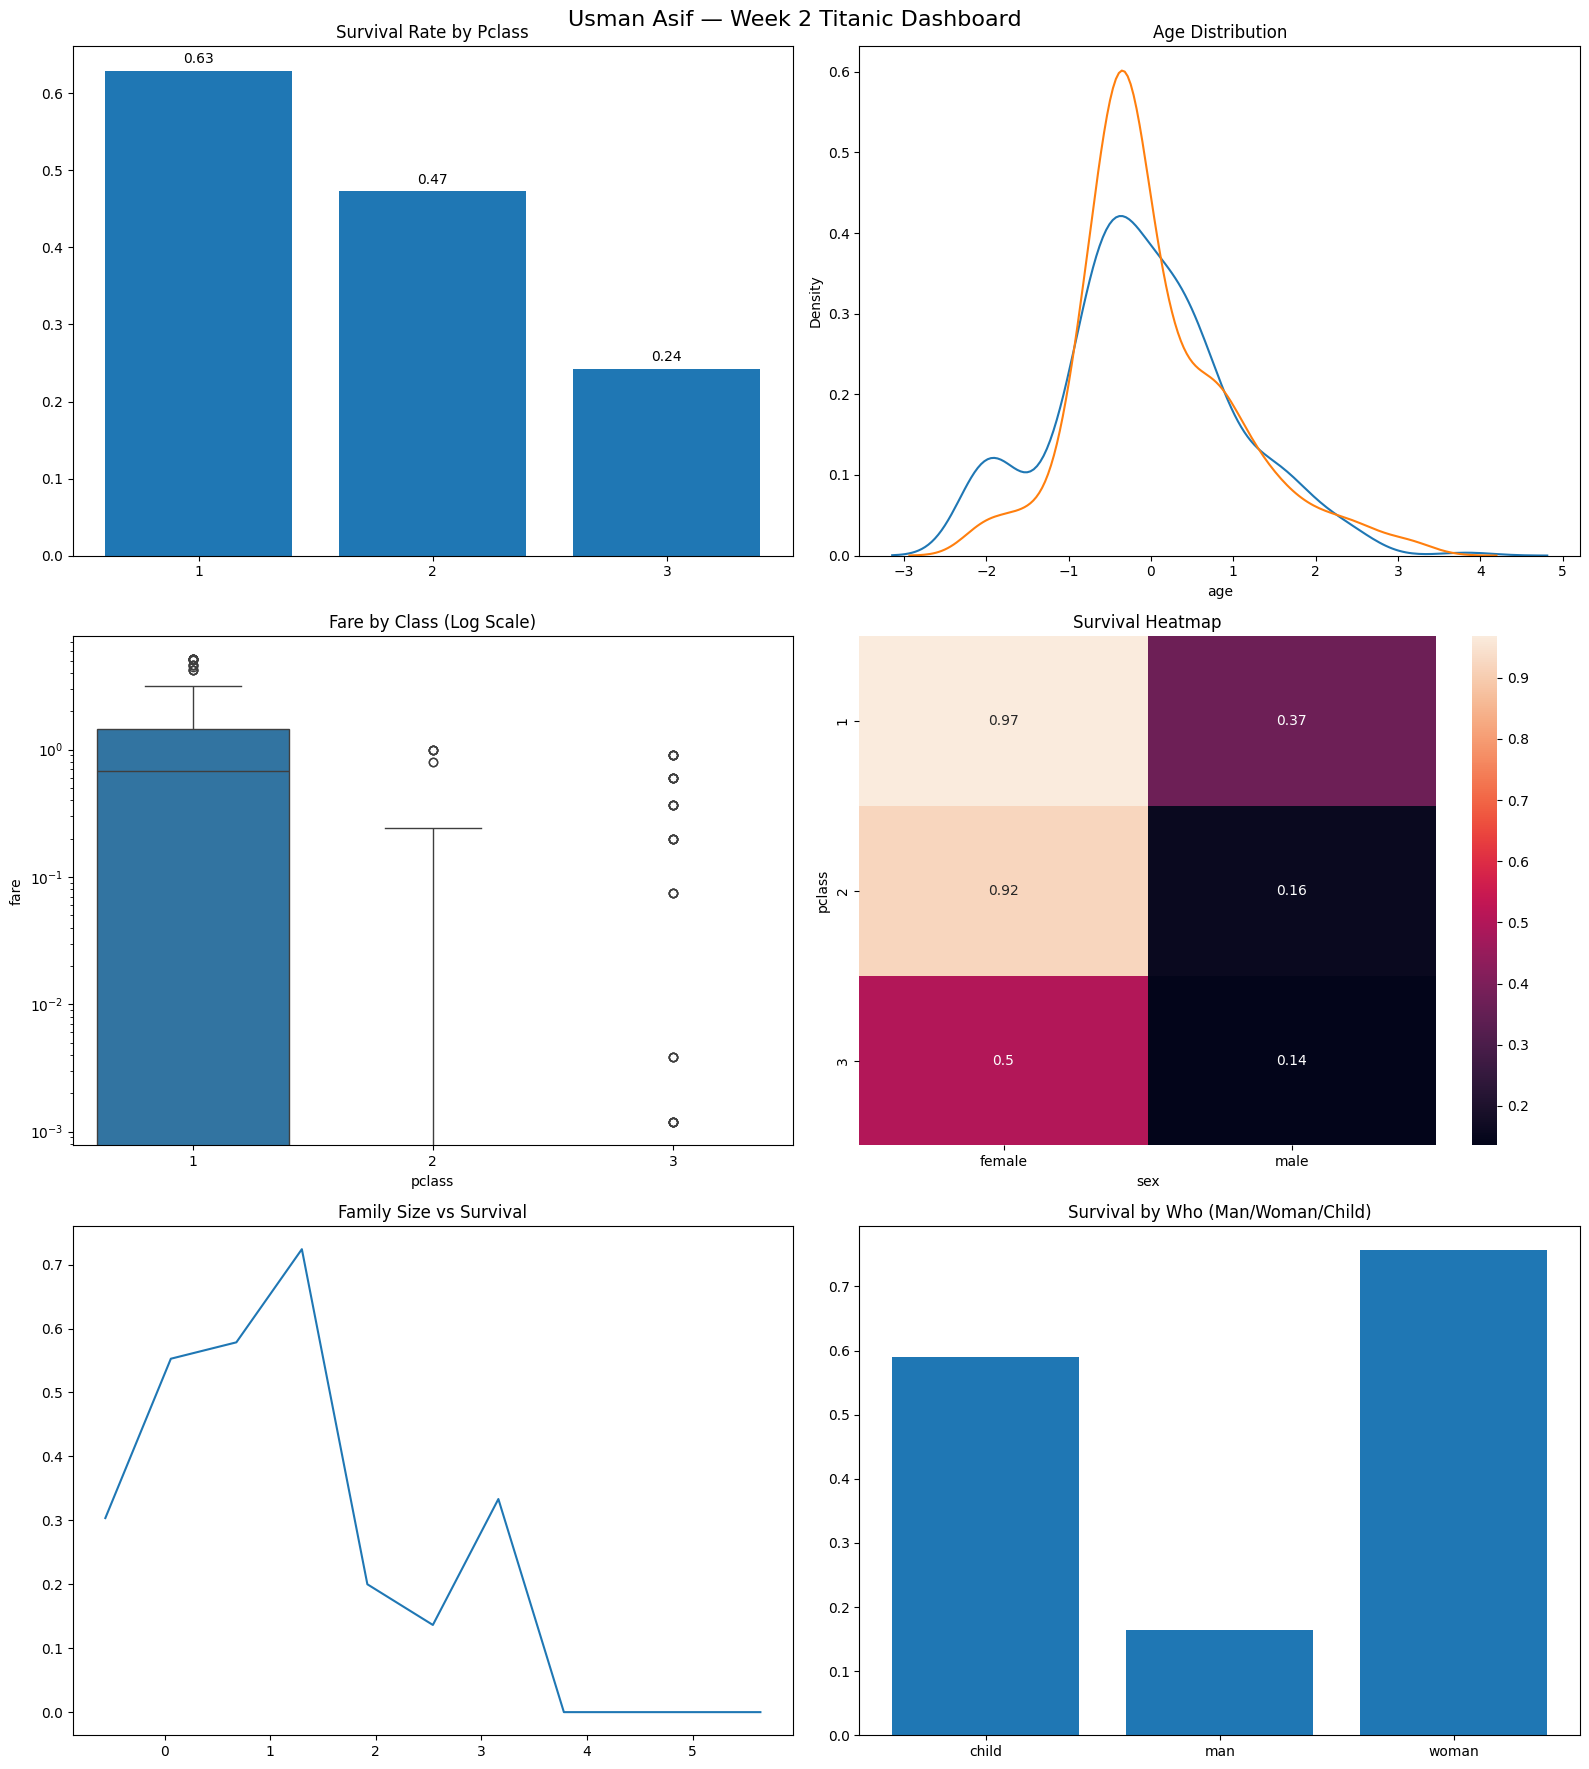

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,2, figsize=(16,18))

# ======================
# Chart 1 - Pclass Survival
# ======================
pclass_survival = df.groupby('pclass', observed=False)['survived'].apply(lambda x: x.astype(int).mean())
axes[0,0].bar(pclass_survival.index.astype(str), pclass_survival.values)

for i, v in enumerate(pclass_survival.values):
    axes[0,0].text(i, v+0.01, f"{v:.2f}", ha='center')

axes[0,0].set_title("Survival Rate by Pclass")

# ======================
# Chart 2 - Age Distribution
# ======================
sns.kdeplot(data=df[df['survived']==1], x='age', ax=axes[0,1], label="Survived")
sns.kdeplot(data=df[df['survived']==0], x='age', ax=axes[0,1], label="Not Survived")
axes[0,1].set_title("Age Distribution")

# ======================
# Chart 3 - Fare Boxplot
# ======================
sns.boxplot(x='pclass', y='fare', data=df, ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title("Fare by Class (Log Scale)")

# ======================
# Chart 4 - Heatmap
# ======================
pivot = df.pivot_table(values='survived', index='pclass', columns='sex', aggfunc=lambda x: x.astype(int).mean(), observed=False)
sns.heatmap(pivot, annot=True, ax=axes[1,1])
axes[1,1].set_title("Survival Heatmap")

# ======================
# Chart 5 - Family Size Survival
# ======================
family_survival = df.groupby('family_size', observed=False)['survived'].apply(lambda x: x.astype(int).mean())
axes[2,0].plot(family_survival.index, family_survival.values)
axes[2,0].set_title("Family Size vs Survival")

# ======================
# Chart 6 - Stacked Bar (TITLE)
# ======================
title_survival = df.groupby('who', observed=False)['survived'].apply(lambda x: x.astype(int).mean())
axes[2,1].bar(title_survival.index.astype(str), title_survival.values)
axes[2,1].set_title("Survival by Who (Man/Woman/Child)")

plt.suptitle("Usman Asif — Week 2 Titanic Dashboard", fontsize=16)
plt.tight_layout()

plt.savefig("titanic_dashboard.png", dpi=150)
plt.show()

In [18]:
from google.colab import files
files.download('titanic_dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Step 16 — Written Analysis Report**

**1. Executive Summary**

This project performs a comprehensive Exploratory Data Analysis (EDA) on the Titanic Survival dataset to understand the key factors that influenced passenger survival during the disaster. The dataset includes demographic, socio-economic, and travel-related attributes such as passenger class, age, gender, fare, family size, and embarkation port. The primary objective of this analysis is to clean the data, perform feature engineering, and extract meaningful insights that explain survival patterns.

The key findings reveal that gender, passenger class, and fare are the most influential factors affecting survival. Female passengers had significantly higher survival rates compared to male passengers, and first-class passengers had a much higher chance of survival compared to third-class passengers. Additionally, passengers who paid higher fares and traveled alone or in smaller family groups showed better survival probabilities. Overall, this analysis provides deep insights into socio-economic and demographic influences on survival during the Titanic disaster.

**2. Data Quality Assessment**

The Titanic dataset contains a mix of numerical and categorical variables, including missing values in critical columns such as age, cabin, and embarked. The most significant data quality issue was found in the cabin column, which had a very high percentage of missing values, making it unreliable for direct analysis. Therefore, it was transformed into a binary feature (has_cabin) to preserve useful information.

The age column also contained missing values, which were handled using group-based median imputation based on passenger class and gender to maintain realistic distribution patterns. The embarked column had only a few missing values, which were filled using the mode. No duplicate records were found in the dataset. Overall, the dataset required moderate preprocessing, but after cleaning, it became suitable for detailed analysis and machine learning tasks.

**3. Feature Engineering Rationale**

Feature engineering was performed to improve the predictive power of the dataset and extract hidden patterns. A new feature called family_size was created by combining sibsp and parch to represent total family members traveling together. From this, is_alone was derived to identify passengers traveling alone, which is important for survival analysis.

Another feature, fare_per_person, was created to better understand economic status relative to group size. The title feature was extracted from passenger names to capture social status (e.g., Mr, Mrs, Miss), which plays an important role in survival probability. Age_group was created by binning ages into meaningful categories (Child, Teen, Adult, Senior), making patterns easier to interpret. Fare_bin was also created using quantile-based grouping to represent ticket price segments. Finally, has_cabin was used to indicate whether cabin information was available, which indirectly reflects passenger class and wealth.

**4. Key Statistical Findings**

The statistical analysis reveals strong patterns in survival behavior. Overall survival rate was approximately 38%. Gender was the strongest factor affecting survival, where female passengers had a survival rate of around 74%, while male passengers had only about 19% survival rate. This clearly reflects the “women and children first” policy during evacuation.

Passenger class also had a significant impact. First-class passengers had the highest survival rate of approximately 63%, while third-class passengers had the lowest survival rate, around 24%. This indicates strong socio-economic influence on survival priority.

Age analysis shows that children had slightly higher survival chances compared to adults and seniors. Additionally, passengers traveling alone had lower survival rates compared to those traveling with family. Fare analysis also showed a positive relationship between ticket price and survival, indicating that wealthier passengers had better access to lifeboats and evacuation priority.

**5. Visualization Insights**

The visual analysis provided clear and strong patterns across multiple dimensions. The bar chart of survival by passenger class clearly showed decreasing survival rates from first class to third class. The KDE plot of age distribution revealed that younger passengers had slightly better survival chances compared to older passengers.

The heatmap of passenger class and gender showed the strongest insight: females in first class had the highest survival probability, while males in third class had the lowest. This visualization was the most informative for predicting survival outcomes.

Box plots of fare across classes showed a strong separation between economic groups, confirming that higher-paying passengers had better survival chances. The family size line plot showed that passengers traveling in small families had better survival rates compared to those in large groups or alone. Overall, the visualizations made it easier to identify key survival patterns and relationships between variables.

**6. Feature Selection Recommendation**

Based on correlation analysis and statistical findings, the most important features for predicting survival include sex_encoded, pclass, fare, family_size, is_alone, age, and title. Among these, gender and passenger class are the strongest predictors, followed by fare and family-related features.

These features capture both socio-economic status and personal demographics, which are critical in determining survival probability. Features like ticket, name, and embarked were less influential and therefore can be excluded from the final machine learning model. Selecting these 5–7 features will help improve model accuracy while reducing complexity and overfitting in the next stage of the project.

**7. Reflection & Lessons Learned**

This project provided a complete hands-on experience in data analysis, preprocessing, and feature engineering using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn. One of the most challenging aspects was handling missing data effectively without introducing bias into the dataset. The group-based imputation for age helped maintain realistic data distribution and improved analysis quality.

The most surprising insight was the extremely strong influence of gender on survival, which was much more significant than other variables. It was also interesting to observe how socio-economic factors such as fare and passenger class played a major role in survival outcomes. If I were to improve this project further, I would experiment with advanced feature selection techniques and machine learning models to validate the predictive power of the selected features. Overall, this project significantly improved my understanding of real-world data analysis and storytelling through data.